In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [3]:
df = pd.read_csv('bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
print("Dataset Shape:", df.shape)
df.info()

print("\nMissing Values:\n", df.isnull().sum())

print("\nTarget Variable Distribution:\n", df['y'].value_counts())

Dataset Shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing Values:
 age          0
job          0
marital      0
education

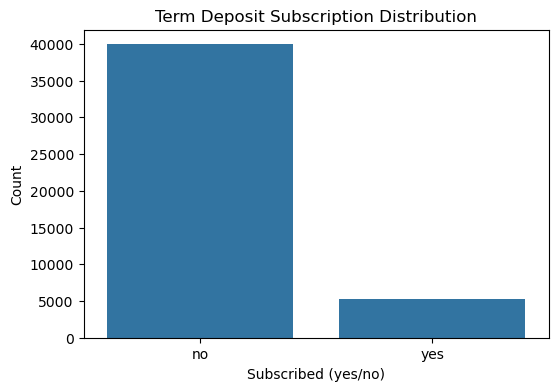

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title('Term Deposit Subscription Distribution')
plt.xlabel('Subscribed (yes/no)')
plt.ylabel('Count')
plt.show()

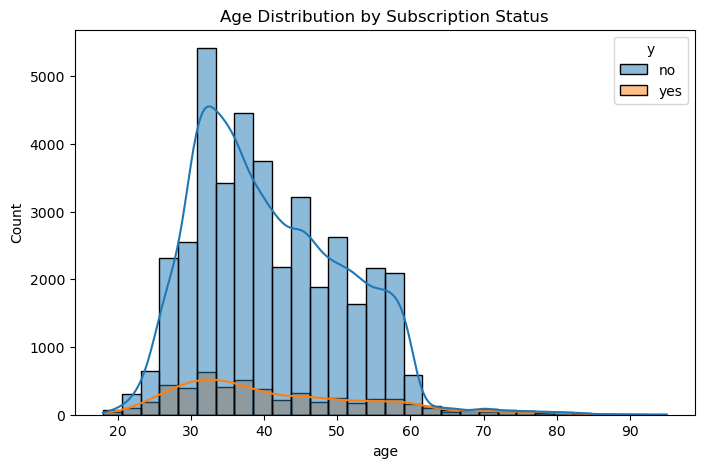

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True)
plt.title('Age Distribution by Subscription Status')
plt.show()

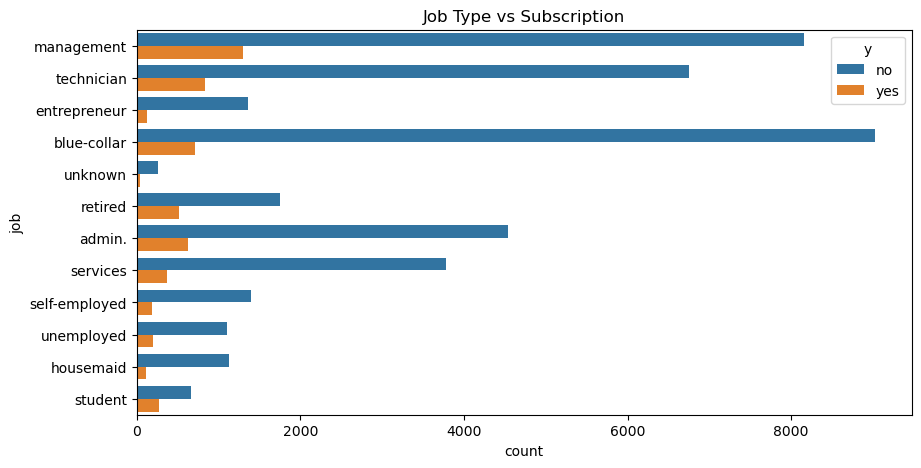

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(y='job', hue='y', data=df)
plt.title('Job Type vs Subscription')
plt.show()

In [8]:
df_encoded = df.copy()

df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape after encoding: (45211, 43)


,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True


In [9]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (36168, 42)
Testing set shape: (9043, 42)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both models trained successfully!")

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Both models trained successfully!


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [13]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, roc_auc_score

log_preds = log_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test)

print("Logistic Regression F1-Score:", f1_score(y_test, log_preds))
print("Random Forest F1-Score:", f1_score(y_test, rf_preds))

print("\nLogistic Regression Classification Report:\n", classification_report(y_test, log_preds))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, rf_preds))

Logistic Regression F1-Score: 0.45248313917841815
Random Forest F1-Score: 0.48931116389548696

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



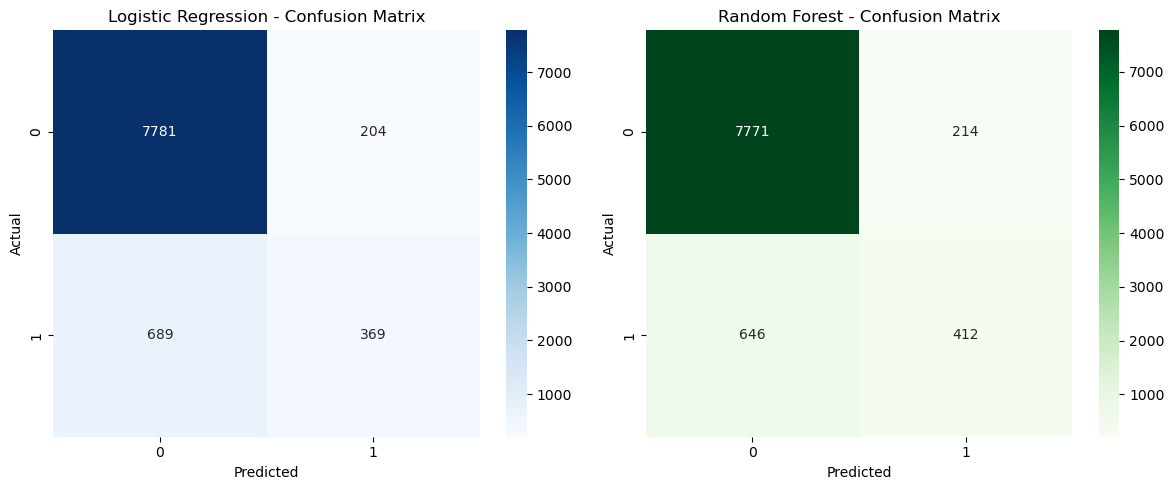

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_log = confusion_matrix(y_test, log_preds)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

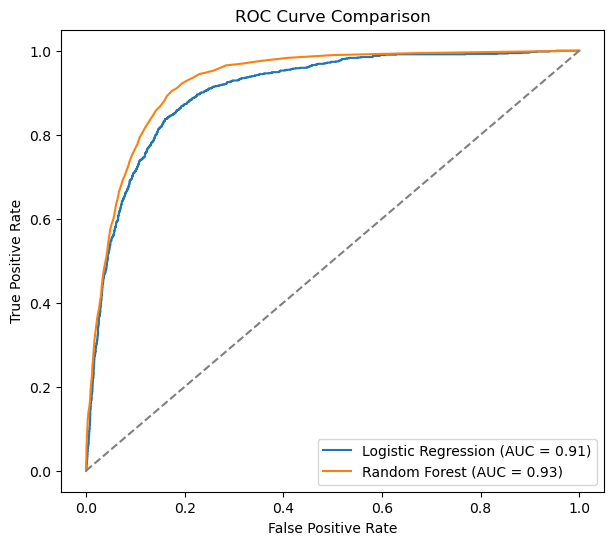

In [15]:
log_probs = log_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, log_probs):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


Explanation for prediction 1:


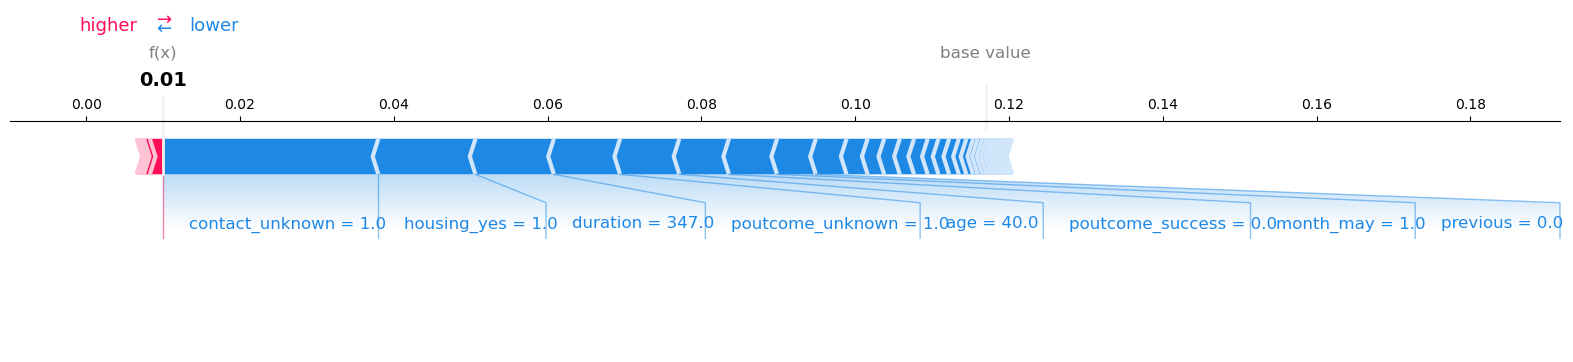


Explanation for prediction 2:


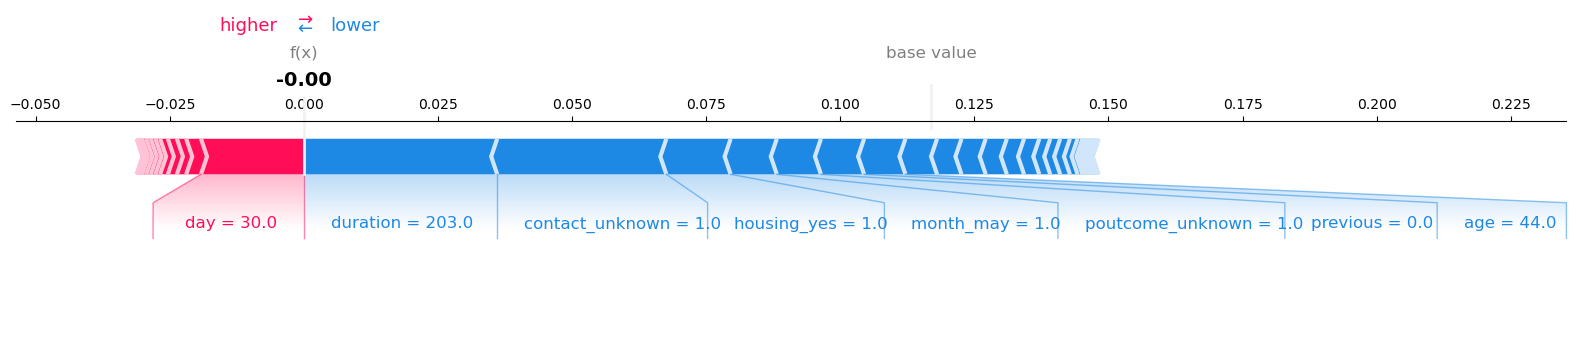


Explanation for prediction 3:


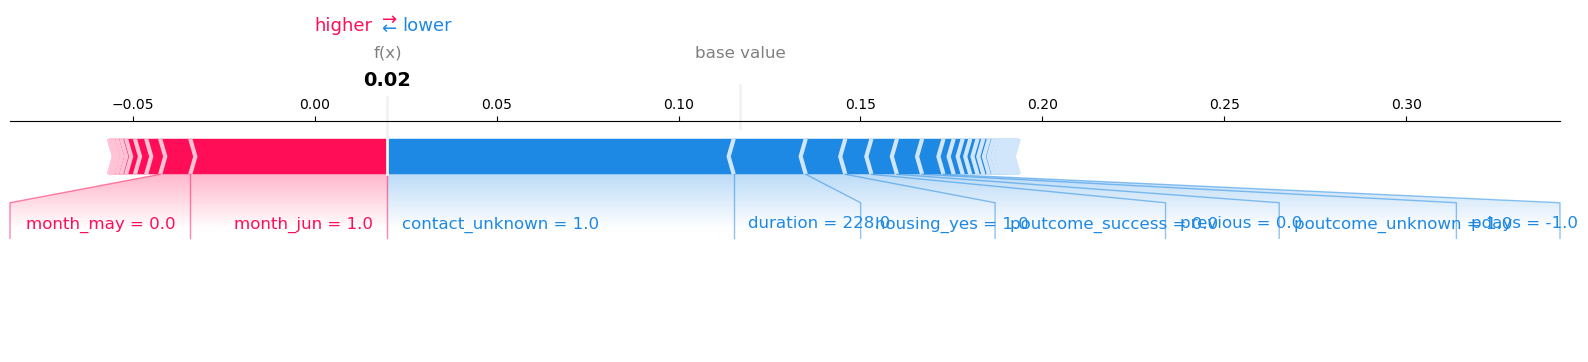


Explanation for prediction 4:


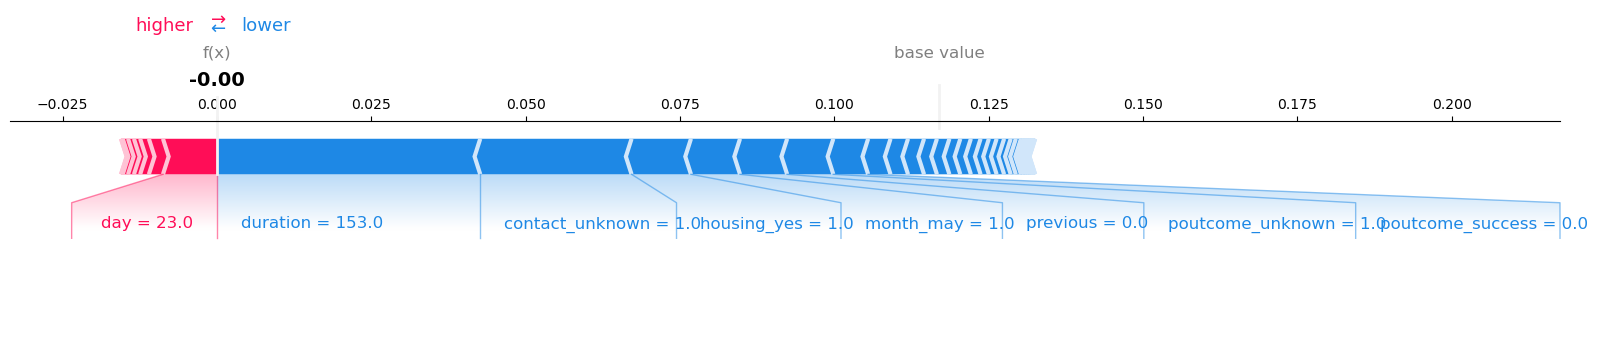


Explanation for prediction 5:


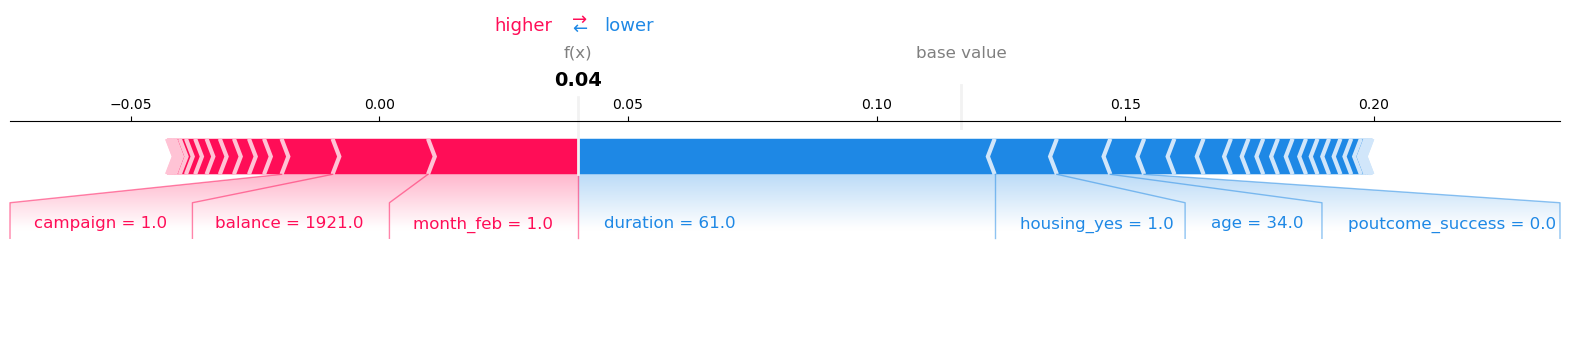

In [18]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test.iloc[:5])

if isinstance(shap_values, list):
    values_to_use = shap_values[1]
    base_value = explainer.expected_value[1]
else:
    values_to_use = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

shap.initjs()
for i in range(5):
    print(f"\nExplanation for prediction {i+1}:")
    shap.force_plot(base_value, values_to_use[i], X_test.iloc[i], matplotlib=True)
    plt.show()

## Conclusion

- The dataset is imbalanced (88% "no" vs 12% "yes"), which affects recall for the minority class.
- Random Forest outperformed Logistic Regression with a higher F1-Score (0.49 vs 0.45) and AUC (0.93 vs 0.91).
- Key features influencing predictions (from SHAP analysis) include call duration, previous campaign outcome, and contact month.
- Both models struggle with recall on the "yes" class, suggesting future work could explore techniques like SMOTE or class-weighting to improve minority class detection.